In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# =============================
# LOAD DATA
# =============================
df = pd.read_csv("../final_dual_fluid_shell_tube_dataset.csv")

# =============================
# DEFINE FEATURES & TARGETS
# =============================
categorical_features = ["tube_fluid", "shell_fluid"]

numeric_features = [
    "shell_diameter", "tube_outer_diameter", "tube_inner_diameter",
    "tube_length", "number_of_tubes", "tube_pitch",
    "baffle_spacing", "number_of_baffles",
    "tube_mass_flow_rate", "shell_mass_flow_rate",
    "tube_inlet_temp", "tube_outlet_temp",
    "shell_inlet_temp", "shell_outlet_temp",
    "tube_thermal_conductivity"
]

X = df[categorical_features + numeric_features]

# Targets
y_Q = np.log1p(df["heat_transfer_rate"])   # log-transform
y_qflux = df["heat_flux"]

In [2]:
# =============================
# TRAIN-TEST SPLIT (NO LEAKAGE)
# =============================
X_train, X_test, yQ_train, yQ_test, yqf_train, yqf_test = train_test_split(
    X, y_Q, y_qflux, test_size=0.2, random_state=42
)

# =============================
# PREPROCESSING PIPELINE
# =============================
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [3]:
# =============================
# FIT TRANSFORMERS
# =============================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# =============================
# SAVE PREPROCESSOR
# =============================
joblib.dump(preprocessor, "preprocessor_dual_fluid.pkl")

print("Preprocessing complete")
print("Train shape:", X_train_processed.shape)
print("Test shape :", X_test_processed.shape)


Preprocessing complete
Train shape: (8000, 23)
Test shape : (2000, 23)


In [4]:
#baseline model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [5]:
# TRAIN BASELINE MODEL
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, yQ_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# PREDICTION
yQ_pred_log = lin_reg.predict(X_test_processed)

In [7]:
# Inverse log transform
yQ_pred = np.expm1(yQ_pred_log)
yQ_true = np.expm1(yQ_test)

In [8]:
# METRICS
mae = mean_absolute_error(yQ_true, yQ_pred)
rmse = np.sqrt(mean_squared_error(yQ_true, yQ_pred))
r2 = r2_score(yQ_true, yQ_pred)

print("LINEAR REGRESSION RESULTS")
print("MAE  (W):", mae)
print("RMSE (W):", rmse)
print("R² score:", r2)

LINEAR REGRESSION RESULTS
MAE  (W): 6669.426246739147
RMSE (W): 12916.984229998232
R² score: 0.8137503178958401


In [9]:
from sklearn.ensemble import RandomForestRegressor

# TRAIN RANDOM FOREST
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, yQ_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [10]:
# PREDICTION
yQ_pred_log = rf.predict(X_test_processed)
yQ_pred = np.expm1(yQ_pred_log)

In [11]:
# METRICS
mae = mean_absolute_error(yQ_true, yQ_pred)
rmse = np.sqrt(mean_squared_error(yQ_true, yQ_pred))
r2 = r2_score(yQ_true, yQ_pred)

print("\nRANDOM FOREST RESULTS")
print("MAE  (W):", mae)
print("RMSE (W):", rmse)
print("R² score:", r2)


RANDOM FOREST RESULTS
MAE  (W): 2842.8213835436673
RMSE (W): 5276.913032913535
R² score: 0.9689162680640623


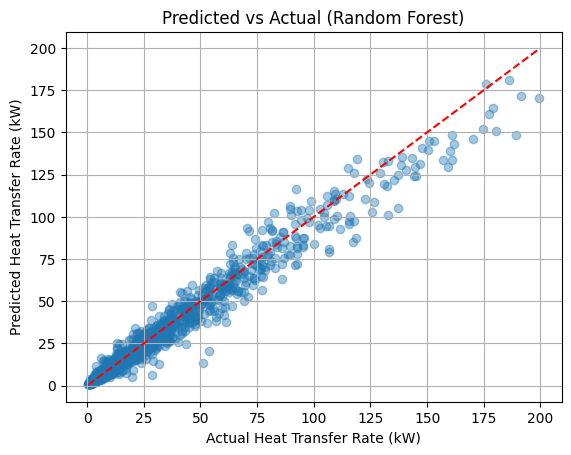

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(yQ_true / 1000, yQ_pred / 1000, alpha=0.4)
plt.plot(
    [yQ_true.min()/1000, yQ_true.max()/1000],
    [yQ_true.min()/1000, yQ_true.max()/1000],
    "r--"
)
plt.xlabel("Actual Heat Transfer Rate (kW)")
plt.ylabel("Predicted Heat Transfer Rate (kW)")
plt.title("Predicted vs Actual (Random Forest)")
plt.grid(True)
plt.show()


In [16]:
rf_train_pred = rf.predict(X_train_processed)
rf_train_pred = np.expm1(rf_train_pred)
yQ_train_true = np.expm1(yQ_train)

r2_train = r2_score(yQ_train_true, rf_train_pred)
print("Train R²:", r2_train)


Train R²: 0.99446545539997


In [20]:
model_info = {
    "model_type": "RandomForestRegressor",
    "train_r2": r2_train,
    "test_r2": r2,
    "features": preprocessor.get_feature_names_out().tolist(),
    "target": "log(heat_transfer_rate)",
    "notes": "Dual-fluid shell-and-tube heat exchanger model"
}

joblib.dump(model_info, "model_metadata.pkl")

print("Model metadata saved")


Model metadata saved


In [19]:
joblib.dump(preprocessor, "preprocessor_dual_fluid.pkl")

print("Preprocessor saved")


Preprocessor saved


In [21]:
# Load saved objects
rf_loaded = joblib.load("random_forest_heat_exchanger_model.pkl")
preprocessor_loaded = joblib.load("preprocessor_dual_fluid.pkl")

# Example: predict on new data
X_new_processed = preprocessor_loaded.transform(X_test)
y_pred_log = rf_loaded.predict(X_new_processed)
y_pred = np.expm1(y_pred_log)

print("Sample prediction (W):", y_pred[:5])


Sample prediction (W): [ 3158.49010073  9669.7868661  14147.97776271 14786.27831704
  7419.32397903]
